# 09 — Voltage-Grid LSTM (SOTA Input Representation)

## Motivation

Notebooks 06–08 extract the **CV-phase** charge curve resampled uniformly in time.  
The LSTM never beat Random Forest because:

1. **Uniform-time resampling** destroys duration (a 45-min CC phase looks the same shape as a 20-min one after resampling to 128 points).
2. **Per-sample z-scoring** destroys absolute magnitude — the LSTM can't distinguish a healthy cycle from a degraded one by shape alone when every curve is zero-mean unit-variance.
3. **CV-only window** discards the CC ramp entirely — the richest degradation signal (rising internal resistance → faster voltage climb → dQ/dV proxy).

## SOTA fix: voltage-aligned windowing

Sample |I|, T, and Δt at **equal voltage increments across a fixed window during CC charging** (3.8 V → 4.2 V).

- Indexing by voltage (not time) preserves absolute current magnitudes.
- Duration is implicit: a degraded cell covers the voltage window faster → fewer real seconds per grid point → the Δt channel encodes health without explicit normalisation.
- We use a **descending grid** (4.2 V → 3.8 V) so valid data leads and any low-voltage truncation falls at the tail — the standard right-padding convention for `pack_padded_sequence`.

## Target

`y = Ct / C_nominal` where `C_nominal = 2.0 Ah` (NASA 18650 rated capacity).  
This avoids the per-battery measured-baseline denominator used by `capacity_retention`, making the metric consistent across future datasets.

## Validation

Leave-One-Battery-Out (LOBO) CV across all 13 retained batteries.  
Per fold: scatter plot (predicted vs actual) + train/val loss curves to diagnose overfitting.

## Experiments (in order)

1. **Baseline** — bidirectional LSTM, no scalars
2. **CNN-LSTM** — Conv1d front-end + bidirectional LSTM (after baseline validated)
3. *(Optional)* Scalar injection (head / lstm-state) if baseline underperforms

---
## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Project paths
ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))

import voltage_grid as vg
import vg_models

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

# Config — mirrors constants in voltage_grid.py
V_LO    = vg.V_LO      # 3.8 V
V_HI    = vg.V_HI      # 4.2 V
N_GRID  = vg.N_GRID    # 128
C_NOM   = vg.C_NOMINAL # 2.0 Ah

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
CACHE   = ROOT / "data/processed/voltage_grid.npz"

# Training hyperparameters
EPOCHS     = 300
PATIENCE   = 50
BATCH_SIZE = 64
LR         = 1e-3

Device: mps


---
## Build voltage-grid dataset

In [2]:
if CACHE.exists():
    print(f"Loading cached dataset from {CACHE}")
    X, mask, y, groups, cidx = vg.load_npz(CACHE)
else:
    print("Extracting voltage-grid curves (first run, takes ~1–2 min)…")
    curve_df = vg.build_voltage_grid_dataset(ROOT)
    print("Attaching labels…")
    X, mask, y, groups, cidx = vg.attach_targets(curve_df, ROOT)
    vg.save_npz(CACHE, X, mask, y, groups, cidx)

print(f"X shape : {X.shape}   (n_samples, n_grid, n_channels)")
print(f"mask    : {mask.shape}  dtype={mask.dtype}")
print(f"y range : [{y.min():.4f}, {y.max():.4f}]")
print(f"Batteries: {sorted(set(groups))}")

Loading cached dataset from ../data/processed/voltage_grid.npz
X shape : (785, 128, 3)   (n_samples, n_grid, n_channels)
mask    : (785, 128)  dtype=bool
y range : [0.3744, 1.0684]
Batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20', 'RW9']


---
## Coverage & sanity diagnostics

In [3]:
# --- Per-battery mean coverage ---
all_bids = sorted(set(groups))
cov_per_bid = {bid: mask[groups == bid].mean() for bid in all_bids}

print("Mean coverage per battery:")
for bid, cov in cov_per_bid.items():
    flag = "  ← partial" if cov < 0.99 else ""
    print(f"  {bid:6s}: {cov:.4f}{flag}")

# Assert controlled batteries are fully covered
ctrl_min_cov = min(cov_per_bid[b] for b in ["B0005","B0006","B0007","B0018"])
assert ctrl_min_cov > 0.99, f"Controlled coverage unexpectedly low: {ctrl_min_cov:.4f}"
print(f"\nControlled min coverage: {ctrl_min_cov:.4f} ✓")

# Target range check
assert 0.35 <= y.min(), f"y.min() unexpectedly low: {y.min():.4f}"
assert y.max() <= 1.10, f"y.max() unexpectedly high: {y.max():.4f}"
print(f"Target range: [{y.min():.4f}, {y.max():.4f}] ✓")

# Mask structure check: valid region should be a contiguous leading block
def _is_leading_block(m: np.ndarray) -> bool:
    """True if all True values come before all False values."""
    if m.all() or not m.any():
        return True
    first_false = np.argmin(m)
    return bool(m[:first_false].all() and not m[first_false:].any())

all_leading = all(_is_leading_block(mask[i]) for i in range(len(mask)))
print(f"Mask is always a contiguous leading block: {all_leading} ✓")

Mean coverage per battery:
  B0005 : 1.0000
  B0006 : 1.0000
  B0007 : 1.0000
  B0018 : 1.0000
  RW1   : 0.7641  ← partial
  RW13  : 0.7402  ← partial
  RW14  : 0.6745  ← partial
  RW15  : 0.6917  ← partial
  RW16  : 0.7469  ← partial
  RW17  : 0.7622  ← partial
  RW19  : 0.7630  ← partial
  RW20  : 0.7588  ← partial
  RW9   : 0.6356  ← partial

Controlled min coverage: 1.0000 ✓
Target range: [0.3744, 1.0684] ✓
Mask is always a contiguous leading block: True ✓


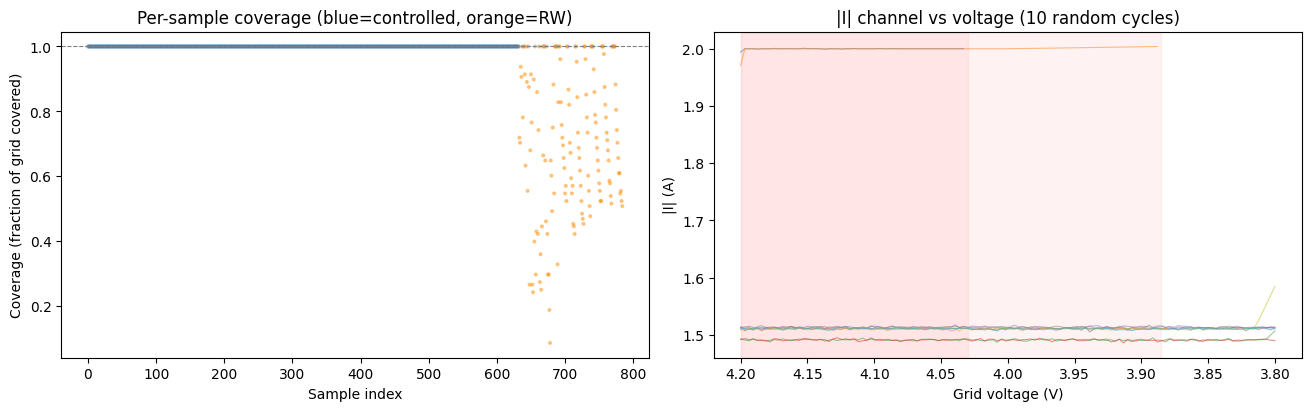

In [4]:
# --- Coverage histogram + example curves ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

# Left: coverage distribution per battery
ax = axes[0]
per_sample_cov = mask.mean(axis=1)
colors = ["steelblue" if b in vg.CONTROLLED_BIDS else "darkorange" for b in groups]
ax.scatter(range(len(per_sample_cov)), per_sample_cov, s=4, alpha=0.4, c=colors)
ax.axhline(1.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Sample index")
ax.set_ylabel("Coverage (fraction of grid covered)")
ax.set_title("Per-sample coverage (blue=controlled, orange=RW)")

# Right: a few example curves per channel
vg_axis = np.linspace(V_HI, V_LO, N_GRID)  # descending voltage axis for display
ax2 = axes[1]
rng = np.random.default_rng(0)
sample_idxs = rng.choice(len(X), size=10, replace=False)
for si in sample_idxs:
    m = mask[si]
    # Plot the |I| channel vs voltage (flip x-axis back to ascending for readability)
    ax2.plot(vg_axis[m], X[si, m, 0], alpha=0.5, lw=0.8)
    if not m.all():
        ax2.axvspan(vg_axis[~m].max(), vg_axis[0], alpha=0.05, color="red")
ax2.set_xlabel("Grid voltage (V)")
ax2.set_ylabel("|I| (A)")
ax2.set_title("|I| channel vs voltage (10 random cycles)")
ax2.invert_xaxis()  # show high-V (start) on the left for intuition

fig.savefig(RESULTS / "09_coverage_diag.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Baseline — Bidirectional LSTM (no scalars)

> Architecture: `VGLSTMReg(n_features=3, hidden=40, dropout=0.35)` — the SOTA baseline.  
> No scalar injection; the model must learn everything from the voltage-aligned curve.  
> Validate with LOBO before adding the CNN front-end.

Expected params: 3-ch input → hidden=40 BiLSTM → 4×40=160 pooled → FC → 1  
≈ 40k parameters.

In [5]:
# Sanity check: single forward pass
demo_model = vg_models.VGLSTMReg(n_features=3, hidden=40, dropout=0.35).to(DEVICE)
n_params = sum(p.numel() for p in demo_model.parameters())
print(f"VGLSTMReg parameters: {n_params:,}")

# Quick forward pass on 4 random samples
with torch.no_grad():
    xb = torch.tensor(X[:4], dtype=torch.float32).to(DEVICE)
    mb = torch.tensor(mask[:4], dtype=torch.bool).to(DEVICE)
    out = demo_model(xb, mb)
print(f"Forward pass output shape: {out.shape}  values: {out.cpu().numpy()}")
del demo_model

VGLSTMReg parameters: 14,561
Forward pass output shape: torch.Size([4])  values: [-0.3364407  -0.08090056 -0.05574628  0.02809721]


In [6]:
# Run LOBO
def make_lstm_baseline():
    return vg_models.VGLSTMReg(n_features=3, hidden=40, dropout=0.35)

print("Running baseline LSTM LOBO (13 folds)…")
res_baseline = vg.run_lobo(
    make_lstm_baseline,
    X, mask, y, groups, cidx,
    DEVICE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    patience=PATIENCE,
    scheduler="plateau",
    progress=True,
)

Running baseline LSTM LOBO (13 folds)…


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/13] held=B0005   MAE=0.0129  R²=0.954  best_ep=7


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/13] held=B0006   MAE=0.0348  R²=0.876  best_ep=16


...

  [11/13] held=RW19    MAE=0.0547  R²=0.796  best_ep=7


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [12/13] held=RW20    MAE=0.0347  R²=0.950  best_ep=15


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [13/13] held=RW9     MAE=0.1754  R²=-0.318  best_ep=8


In [7]:
# Aggregate metrics
agg_baseline = vg.aggregate(res_baseline)
print("Baseline LSTM — aggregate LOBO metrics")
print(f"  MAE  : {agg_baseline['mae']:.4f} ± {agg_baseline['mae_std']:.4f}")
print(f"  RMSE : {agg_baseline['rmse']:.4f} ± {agg_baseline['rmse_std']:.4f}")
print(f"  R²   : {agg_baseline['r2']:.4f} ± {agg_baseline['r2_std']:.4f}")
print(f"  Skill: {agg_baseline['skill']:.4f}")
print(f"  Spearman: {agg_baseline['spearman']:.4f}")

# RW1 and RW9 breakout (partial-coverage batteries)
for bid in ["RW1", "RW9"]:
    fd = next((f for f in res_baseline if f["battery"] == bid), None)
    if fd:
        m = fd["metrics"]
        print(f"  {bid}: MAE={m['mae']:.4f}  R²={m['r2']:.3f}")

Baseline LSTM — aggregate LOBO metrics
  MAE  : 0.0622 ± 0.0441
  RMSE : 0.0759 ± 0.0490
  R²   : 0.5775 ± 0.6083
  Skill: 0.5209
  Spearman: 0.8750
  RW1: MAE=0.1430  R²=-1.221
  RW9: MAE=0.1754  R²=-0.318


  Saved: ../results/09_baseline_lstm_per_fold.png


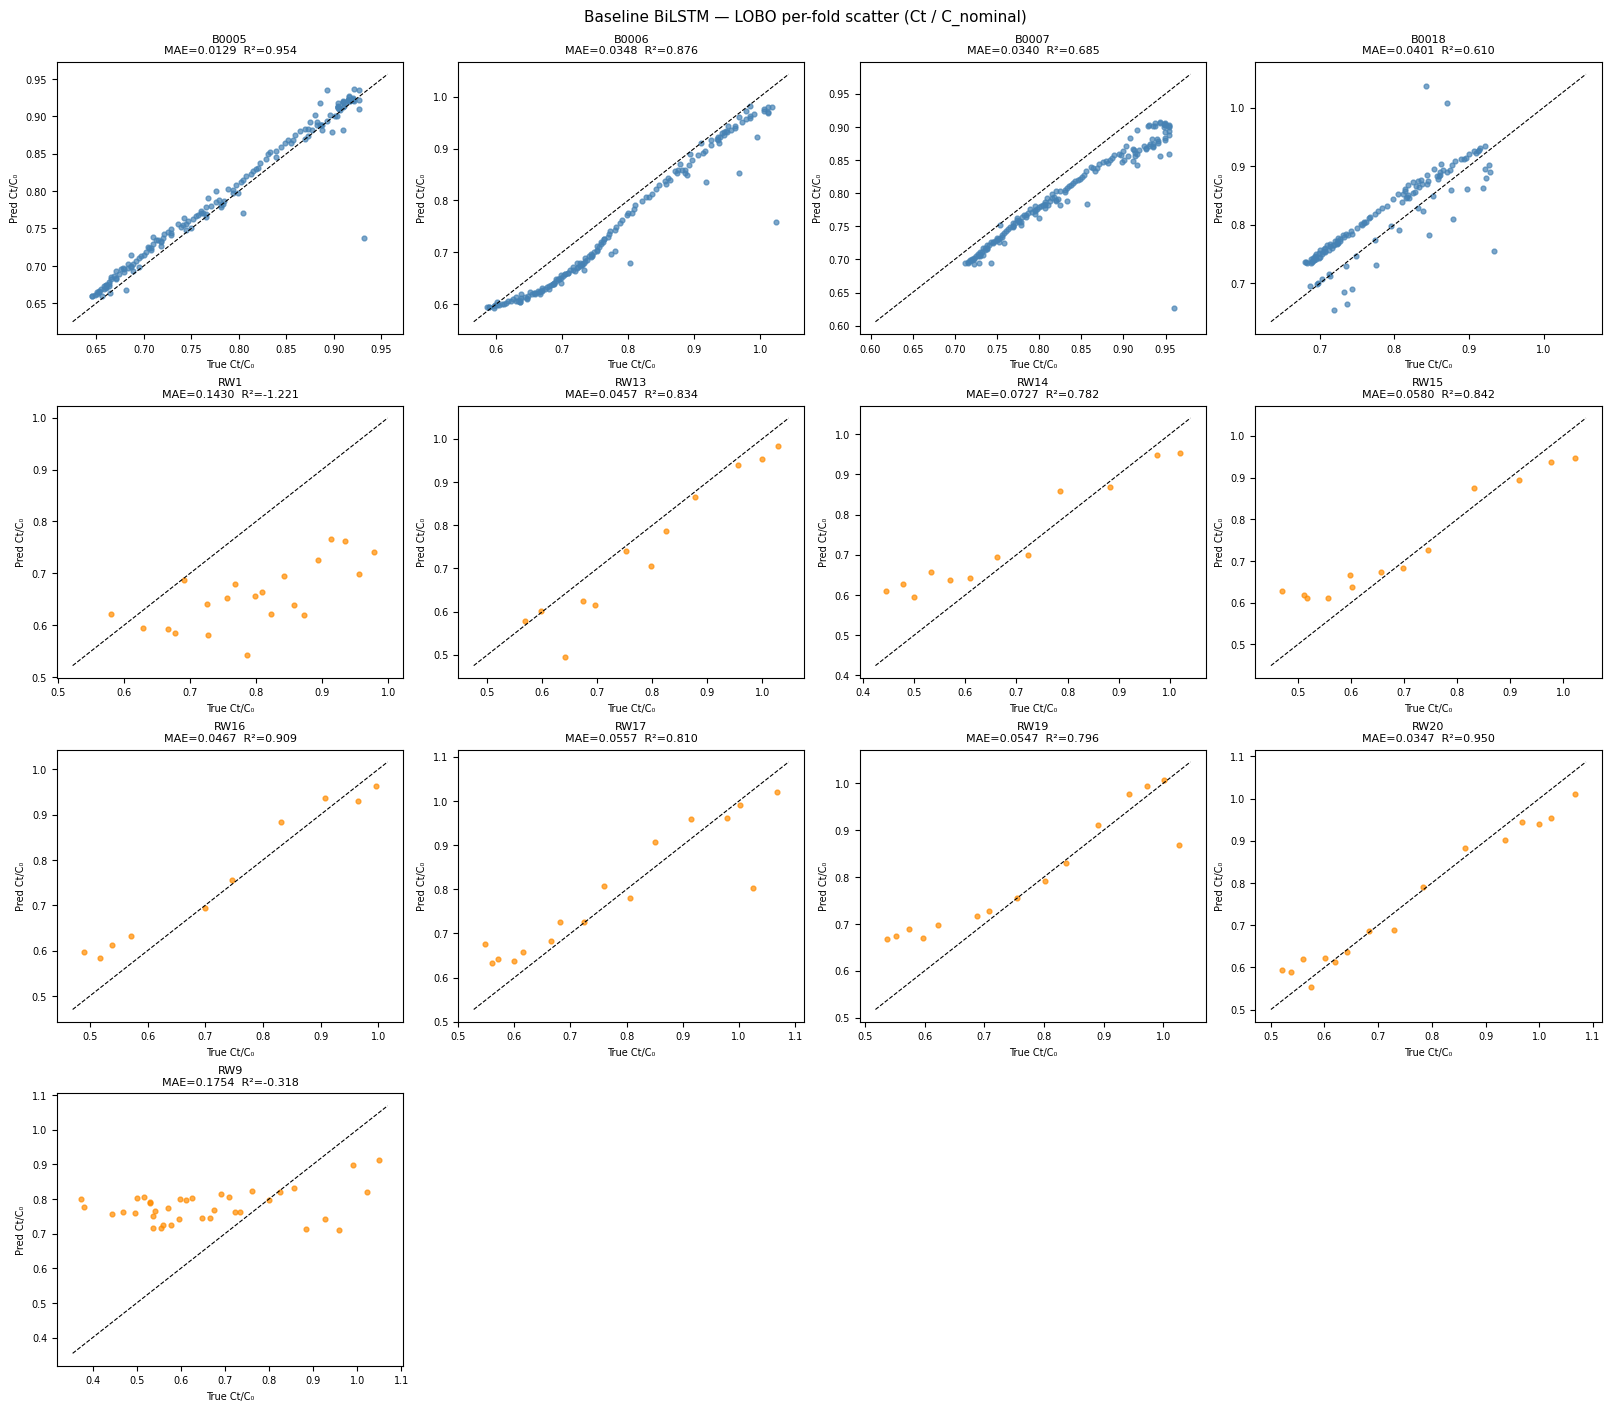

In [8]:
# Per-fold scatter
vg.per_fold_scatter(
    res_baseline,
    "Baseline BiLSTM — LOBO per-fold scatter (Ct / C_nominal)",
    save_path=RESULTS / "09_baseline_lstm_per_fold.png",
)

Insights from per fold:
- controlled batteries look VERY GOOD. Better than RF i think. Perhaps overfit
- RW look great as well
- RW1 undershooting
- RW9 is flat (RF also has this tail) under True Ct/Cn 0.5 

  Saved: ../results/09_baseline_lstm_loss_curves.png


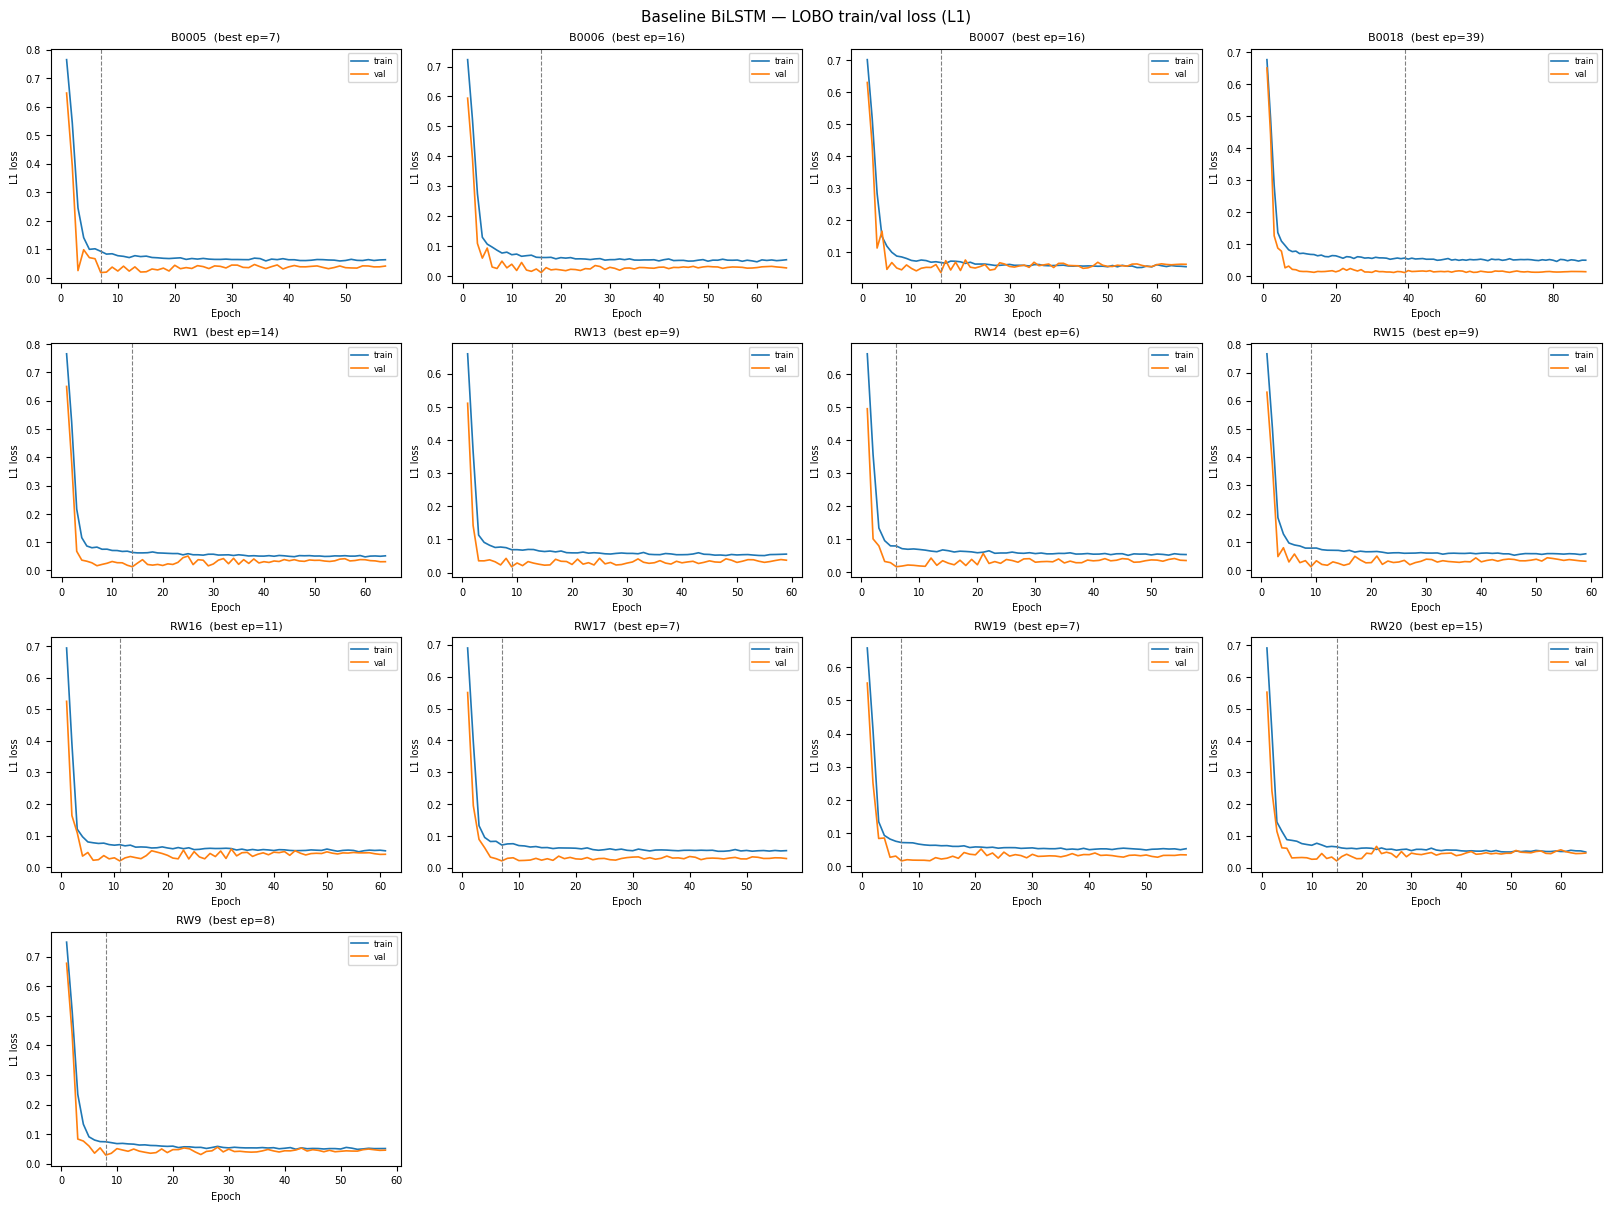

In [9]:
# Train / val loss curves
vg.per_fold_loss_curves(
    res_baseline,
    "Baseline BiLSTM — LOBO train/val loss (L1)",
    save_path=RESULTS / "09_baseline_lstm_loss_curves.png",
)

---
## CNN-LSTM

> Add a Conv1d front-end (2 blocks, kernel 5 + 3, GroupNorm, same-padding)  
> before the bidirectional LSTM to capture local voltage-domain features  
> (e.g. the shoulder at the CC→CV transition).  
> **Only run after inspecting the baseline scatter and loss curves.**

In [37]:
from importlib import reload
reload(vg_models)
import vg_models

In [38]:
demo_cnn = vg_models.VGCNNLSTM(n_features=3, cnn_ch=8, hidden=40, dropout=0.35).to(DEVICE)
n_params_cnn = sum(p.numel() for p in demo_cnn.parameters())
print(f"VGCNNLSTM parameters: {n_params_cnn:,}")
with torch.no_grad():
    out_cnn = demo_cnn(torch.tensor(X[:4], dtype=torch.float32).to(DEVICE),
                       torch.tensor(mask[:4], dtype=torch.bool).to(DEVICE))
print(f"CNN-LSTM forward pass: {out_cnn.shape}")
del demo_cnn

VGCNNLSTM parameters: 16,305
CNN-LSTM forward pass: torch.Size([4])


In [39]:
def make_cnnlstm():
    return vg_models.VGCNNLSTM(n_features=3, cnn_ch=8, hidden=40, dropout=0.35)

print("Running CNN-LSTM LOBO (13 folds)…")
res_cnnlstm = vg.run_lobo(
    make_cnnlstm,
    X, mask, y, groups, cidx,
    DEVICE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    patience=PATIENCE,
    scheduler="plateau",
    progress=True,
)

Running CNN-LSTM LOBO (13 folds)…


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/13] held=B0005   MAE=0.0845  R²=0.141  best_ep=21


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/13] held=B0006   MAE=0.0798  R²=0.512  best_ep=62


...

  [11/13] held=RW19    MAE=0.0741  R²=0.700  best_ep=26


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [12/13] held=RW20    MAE=0.0755  R²=0.724  best_ep=38


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [13/13] held=RW9     MAE=0.1676  R²=-0.285  best_ep=34


In [40]:
agg_cnnlstm = vg.aggregate(res_cnnlstm)
print("CNN-LSTM — aggregate LOBO metrics")
print(f"  MAE  : {agg_cnnlstm['mae']:.4f} ± {agg_cnnlstm['mae_std']:.4f}")
print(f"  RMSE : {agg_cnnlstm['rmse']:.4f} ± {agg_cnnlstm['rmse_std']:.4f}")
print(f"  R²   : {agg_cnnlstm['r2']:.4f} ± {agg_cnnlstm['r2_std']:.4f}")
print(f"  Skill: {agg_cnnlstm['skill']:.4f}")
print(f"  Spearman: {agg_cnnlstm['spearman']:.4f}")

for bid in ["RW1", "RW9"]:
    fd = next((f for f in res_cnnlstm if f["battery"] == bid), None)
    if fd:
        m = fd["metrics"]
        print(f"  {bid}: MAE={m['mae']:.4f}  R²={m['r2']:.3f}")

CNN-LSTM — aggregate LOBO metrics
  MAE  : 0.0868 ± 0.0433
  RMSE : 0.1017 ± 0.0467
  R²   : 0.2192 ± 0.9390
  Skill: 0.2770
  Spearman: 0.8752
  RW1: MAE=0.1879  R²=-2.611
  RW9: MAE=0.1676  R²=-0.285


  Saved: ../results/09_cnnlstm_per_fold.png


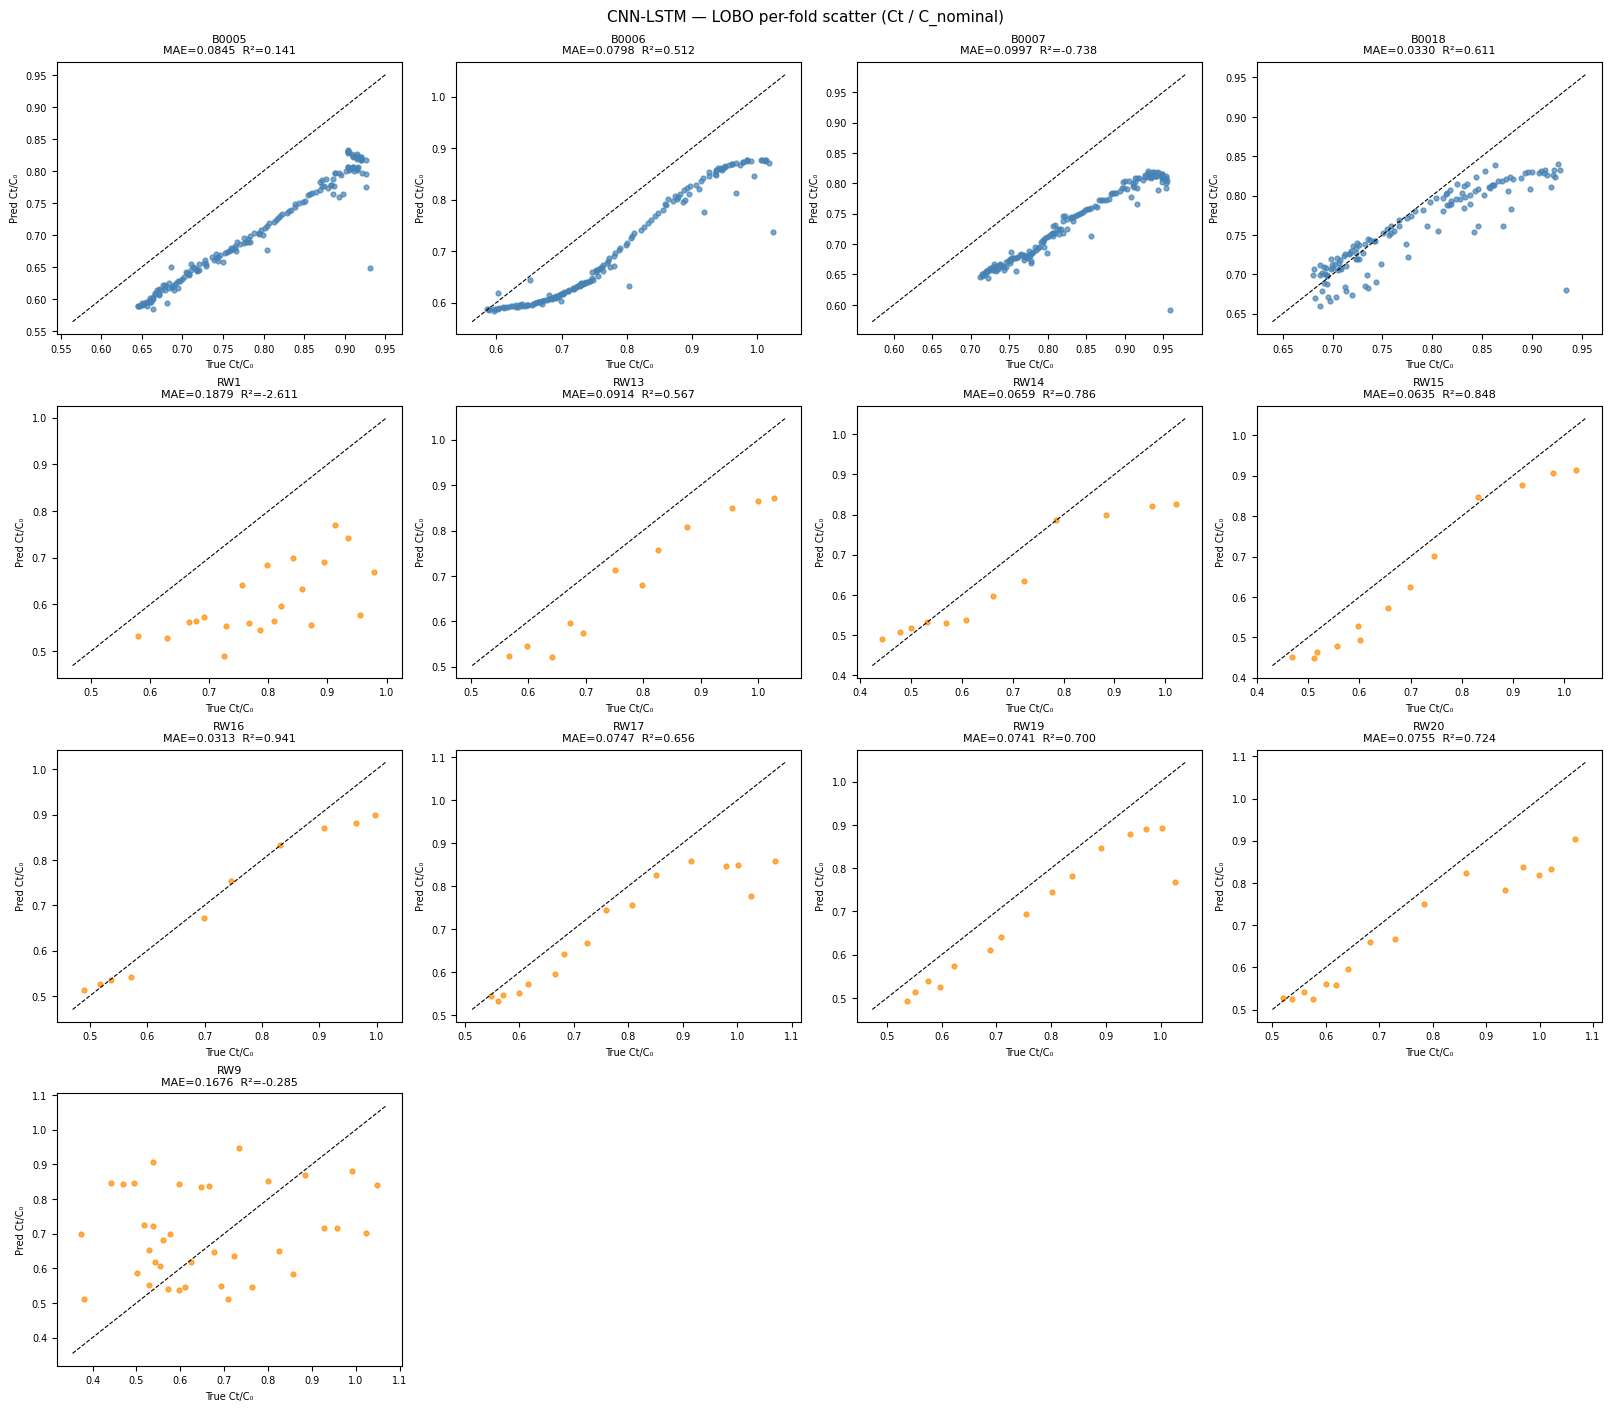

In [41]:
vg.per_fold_scatter(
    res_cnnlstm,
    "CNN-LSTM — LOBO per-fold scatter (Ct / C_nominal)",
    save_path=RESULTS / "09_cnnlstm_per_fold.png",
)

  Saved: ../results/09_cnnlstm_loss_curves.png


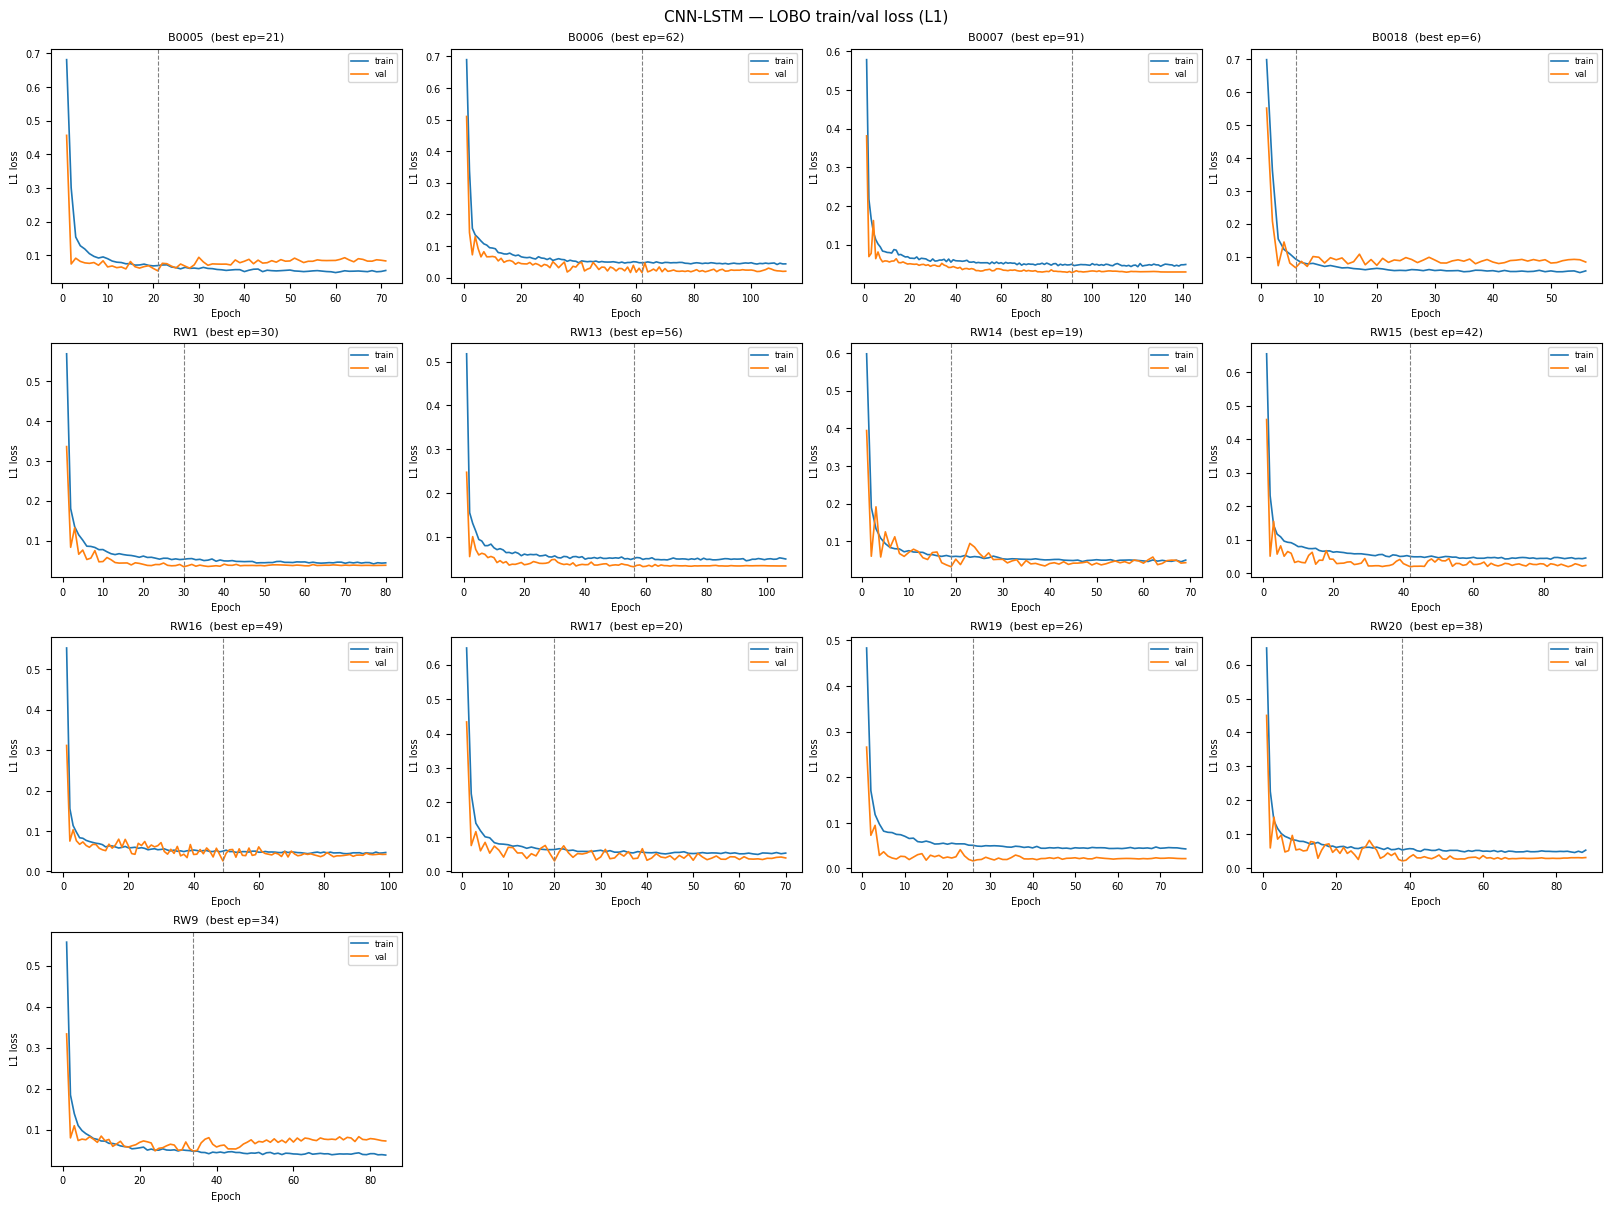

In [42]:
vg.per_fold_loss_curves(
    res_cnnlstm,
    "CNN-LSTM — LOBO train/val loss (L1)",
    save_path=RESULTS / "09_cnnlstm_loss_curves.png",
)

---
## Comparison table

In [44]:
import pandas as pd
from IPython.display import display

# Explicit order: LSTM first, +CNN second
ARM_ORDER = [("LSTM", res_baseline, agg_baseline), ("+CNN", res_cnnlstm, agg_cnnlstm)]

# Columns where lower is better (all others: higher is better)
LOWER_BETTER = {"MAE", "RMSE", "RW1 MAE", "RW9 MAE"}

# ── Aggregate summary ─────────────────────────────────────────────────────────
# Build two parallel dicts: one with display strings, one with raw floats for comparison
agg_str, agg_num = {}, {}
for arm, folds, agg in ARM_ORDER:
    rw1 = next(f for f in folds if f["battery"] == "RW1")["metrics"]
    rw9 = next(f for f in folds if f["battery"] == "RW9")["metrics"]
    agg_str[arm] = {
        "MAE":      f"{agg['mae']:.4f} ± {agg['mae_std']:.4f}",
        "RMSE":     f"{agg['rmse']:.4f} ± {agg['rmse_std']:.4f}",
        "R²":       f"{agg['r2']:.4f} ± {agg['r2_std']:.4f}",
        "Skill":    f"{agg['skill']:.4f}",
        "Spearman": f"{agg['spearman']:.4f}",
        "RW1 MAE":  f"{rw1['mae']:.4f}",
        "RW1 R²":   f"{rw1['r2']:.3f}",
        "RW9 MAE":  f"{rw9['mae']:.4f}",
        "RW9 R²":   f"{rw9['r2']:.3f}",
    }
    agg_num[arm] = {k: float(v.split()[0]) for k, v in agg_str[arm].items()}

df_str = pd.DataFrame(agg_str).T
df_num = pd.DataFrame(agg_num).T

def _bold_better(col):
    name = col.name
    better_idx = df_num[name].idxmin() if name in LOWER_BETTER else df_num[name].idxmax()
    return ["font-weight: bold" if idx == better_idx else "" for idx in df_str.index]

print("=== Aggregate ===")
display(df_str.style.apply(_bold_better))
df_str.to_csv(str(RESULTS / "09_comparison_metrics.csv"))

# ── Per-fold breakdown ────────────────────────────────────────────────────────
fold_rows = []
for arm, folds, _ in ARM_ORDER:
    for f in folds:
        m = f["metrics"]
        fold_rows.append({
            "Model":   arm,
            "Battery": f["battery"],
            "MAE":     round(m["mae"],   4),
            "RMSE":    round(m["rmse"],  4),
            "R²":      round(m["r2"],    3),
            "Skill":   round(m["skill"], 3),
            "best_ep": f["best_epoch"],
        })

df_folds = pd.DataFrame(fold_rows).set_index(["Model", "Battery"])
df_pivot = df_folds.unstack("Model")[  # reorder model columns explicitly
    [(metric, arm) for metric in ["MAE","RMSE","R²","Skill","best_ep"]
                   for arm in ["LSTM", "+CNN"]]
]

LOWER_BETTER_FOLD = {"MAE", "RMSE"}

def _bold_fold(col):
    metric = col.name[0]
    if metric not in {"MAE", "RMSE", "R²", "Skill"}:
        return [""] * len(col)
    # compare LSTM vs +CNN for this metric across same battery rows
    lstm_col = df_pivot[(metric, "LSTM")]
    cnn_col  = df_pivot[(metric, "+CNN")]
    model    = col.name[1]
    if metric in LOWER_BETTER_FOLD:
        lstm_wins = lstm_col <= cnn_col
    else:
        lstm_wins = lstm_col >= cnn_col
    wins = lstm_wins if model == "LSTM" else ~lstm_wins
    return ["font-weight: bold" if w else "" for w in wins]

print("\n=== Per-fold ===")
display(df_pivot.style.apply(_bold_fold))
df_pivot.to_csv(str(RESULTS / "09_per_fold_metrics.csv"))
print(f"Saved to {RESULTS}")


=== Aggregate ===


,MAE,RMSE,R²,Skill,Spearman,RW1 MAE,RW1 R²,RW9 MAE,RW9 R²
LSTM,0.0622 ± 0.0441,0.0759 ± 0.0490,0.5775 ± 0.6083,0.5209,0.8750,0.1430,-1.221,0.1754,-0.318
+CNN,0.0868 ± 0.0433,0.1017 ± 0.0467,0.2192 ± 0.9390,0.2770,0.8752,0.1879,-2.611,0.1676,-0.285



=== Per-fold ===


Saved to ../results


Conclusion before adding data: 
The voltage aligned LSTM can now match RF, while the CNN-LSTM performs slightly better on RW batteries but worse on controlled ones. 

Note: the Spearman is essentially tied (0.8750 vs 0.8752) meaning both models rank degradation correctly. The CNN's problem is absolute calibration on the minority. This is explained by the data distribution (only 2 control vs 9 RW).